# 0 · Los datos y el pipeline

**El problema:** detectar **campañas con rinde anómalo** por departamento (soja/maíz,
Argentina, 1981–2024) usando solo variables climáticas. Es **no supervisado**: el modelo
entrena solo con campañas normales y nunca ve la etiqueta.

Esta serie de notebooks es reproducible de punta a punta: cada uno **entrena los modelos
de verdad** (no lee resultados guardados). Abrí cualquiera, "Run all", y sale todo.

| nb | contenido |
|---|---|
| **0** | los datos, la etiqueta `z_rinde`, splits y normalización |
| **1** | cómo se evalúa + baselines (Isolation Forest, One-Class SVM) |
| **2** | autoencoders: **AE y DAE** (+ IForest/OCSVM sobre su latente) |
| **3** | **VAE** y el score `recon_prob` (+ latente + t-SNE) |
| **4** | **seed-ensemble** = el modelo final (+ latente + t-SNE) |
| **5** | el **techo estructural** (por qué nadie pasa de ~0.6) |
| **6** | features nuevas (agro / NDVI / ERA5) |
| **7** | métodos modernos, leaderboard y conclusiones |

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## 1 · El panel
Una fila = un (departamento, campaña, cultivo). Columnas: identificadores, `rinde_kgha`
(el objetivo) y 54 features climáticas (7 variables NASA POWER × 7 meses Sep–Mar + ONI ×
5 meses).

In [2]:
panel = data.load_panel()
print("shape:", panel.shape)
panel[["provincia","departamento","campania","cultivo","rinde_kgha"]].head()

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
shape: (20755, 77)


,provincia,departamento,campania,cultivo,rinde_kgha
0,BUENOS AIRES,25 De Mayo,1981/82,soja,2600.0
1,BUENOS AIRES,9 De Julio,1981/82,soja,1400.0
2,BUENOS AIRES,Alberti,1981/82,soja,1800.0
3,BUENOS AIRES,Arrecifes,1981/82,soja,2207.0
4,BUENOS AIRES,Baradero,1981/82,soja,2000.0


## 2 · La etiqueta proxy `z_rinde`
No hay etiquetas de "anomalía"; las definimos: cuánto cae el rinde respecto de la **media
móvil de 5 años del propio departamento**.

`z_rinde = (rinde − media_móvil) / desvío_móvil`  → `anomalía = z_rinde < −1.5`

Se calcula con `shift(1)` (solo pasado, sin leakage), agrupando por
`[provincia, departamento, cultivo]`. **El modelo nunca la ve — es solo para evaluar.**

In [3]:
panel_z = data.compute_z_rinde(panel)
print("tasa de anomalías por cultivo:")
print((panel_z.groupby("cultivo")["anomalia"].mean()*100).round(1).astype(str) + " %")

tasa de anomalías por cultivo:
cultivo
maiz    10.5 %
soja    12.8 %
Name: anomalia, dtype: str


### La serie de rinde de un departamento, con sus anomalías

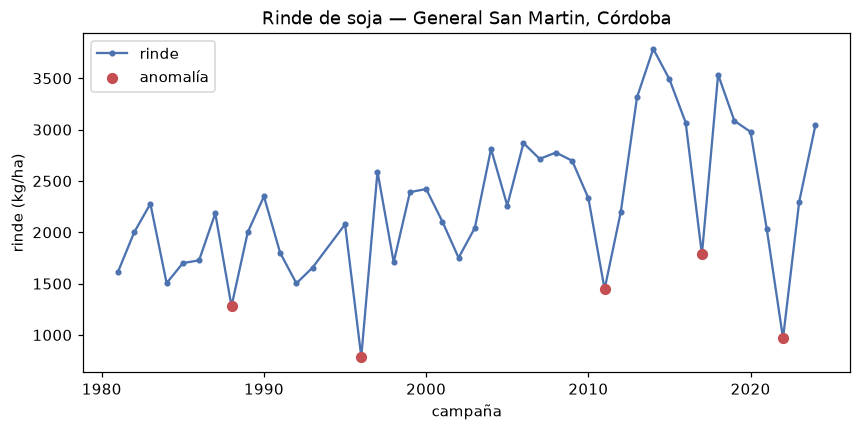

In [4]:
d = panel_z[(panel_z.cultivo=="soja") & (panel_z.provincia=="CORDOBA")]
d = d[d.departamento==d.departamento.value_counts().idxmax()].sort_values("campania_inicio")
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(d.campania_inicio, d.rinde_kgha, "-o", ms=3, color=lab.C_NORMAL, label="rinde")
an = d[d.anomalia==1]
ax.scatter(an.campania_inicio, an.rinde_kgha, color=lab.C_ANOM, zorder=5, s=40, label="anomalía")
ax.set_xlabel("campaña"); ax.set_ylabel("rinde (kg/ha)")
ax.set_title(f"Rinde de soja — {d.departamento.iloc[0]}, Córdoba"); ax.legend(); plt.show()

## 3 · Features, splits y normalización
- **Features (X):** 54 columnas climáticas. NO incluyen el rinde.
- **Split temporal** (no aleatorio): **solo train (≤2020) y test (≥2021)**. No hay
  validación — el bloque 2018–2020 se pliega al train (ver recuadro abajo).
- **Train normal:** del train se excluyen las anomalías y los años de sequía
  generalizada (`config.EXCLUDED_TRAIN_YEARS = [1988,1996,2008,2017]`) → el modelo
  aprende solo "lo normal".
- **Normalización** z-score por departamento, con stats calculadas SOLO en train normal
  (sin leakage).

Todo eso lo arma `build_crop_dataset`. Es la única "caja" del pipeline; el resto de los
notebooks entrenan a la vista sobre su salida.

In [5]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


`ds.X_train` (campañas normales) va al `fit()` de cualquier detector; `ds.X_test`
se puntúa con `score_samples()` (mayor = más anómalo) y se compara contra `ds.y_test`.

> **¿Por qué no hay validación?** Probamos con un val 2018–2020 y resultó **ciego**: sus
> anomalías son de años sin sequía grande → sin firma climática → su PR-AUC daba ≈ azar
> para *todos* los modelos, así que no servía para seleccionar. Plegarlo al train aporta 3
> años más de campañas normales (y acerca el train al clima de test). El *early stopping*
> de los autoencoders usa un 15% interno del train, no este split. La selección de HP
> (nb 3) se ilustra en **test**, con el *data snooping* declarado.